In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Subset, random_split

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24,24)),
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])

train_dataset=datasets.ImageFolder(root=r'C:\Users\Asus\Desktop\8',transform=transform)

dataloader=torch.utils.data.DataLoader(train_dataset,batch_size=32,shuffle=True)

In [3]:
class Generator(nn.Module):
    def __init__(self,latent_dim):
        super(Generator,self).__init__()
        self.model=nn.Sequential(
            nn.Linear(latent_dim,64*3*3),
            nn.ReLU(),
            nn.Unflatten(1,(64,3,3)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64,momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32,momentum=0.78),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,16,kernel_size=3,padding=1),
            nn.BatchNorm2d(16,momentum=0.78),
            nn.ReLU(),
            nn.Conv2d(16,1,kernel_size=3,padding=1),
            nn.Tanh()
        )
    def forward(self,z):
        img=self.model(z)
        return img

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator,self).__init__()
        self.model=nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,stride=2,padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(16,32,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(32,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(64,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(64*3*3,1),
            nn.Sigmoid()
        )
    def forward(self,img):
        validity=self.model(img)
        return validity

In [5]:
latent_dim=100
lr=0.0002
beta1=0.5
beta2=0.999
num_epochs=20

In [6]:
generator=Generator(latent_dim).to(device)
discriminator=Discriminator().to(device)
adversarial_loss=nn.BCELoss()
optimizer_G=optim.Adam(generator.parameters(),lr=lr,betas=(beta1,beta2))
optimizer_D=optim.Adam(discriminator.parameters(),lr=lr,betas=(beta1,beta2))

Epoch [1/20]                        Batch 337/337 Discriminator Loss: 0.6838 Generator Loss: 0.7406


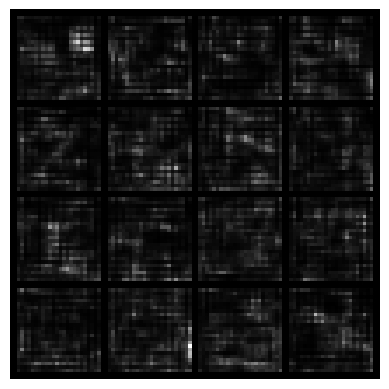

Epoch [2/20]                        Batch 337/337 Discriminator Loss: 0.7207 Generator Loss: 0.6779


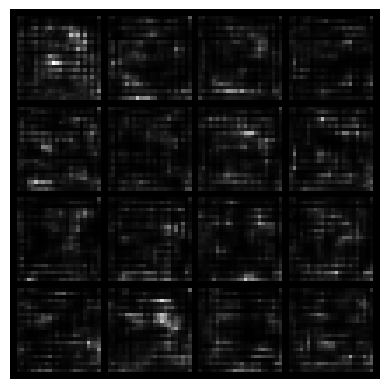

Epoch [3/20]                        Batch 337/337 Discriminator Loss: 0.7009 Generator Loss: 0.7050


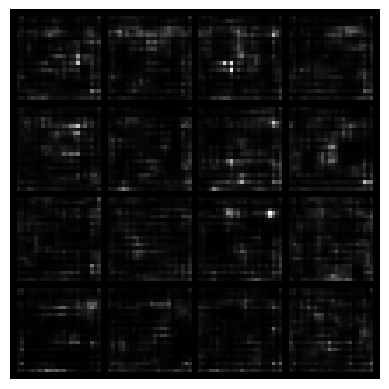

Epoch [4/20]                        Batch 337/337 Discriminator Loss: 0.6857 Generator Loss: 0.7053


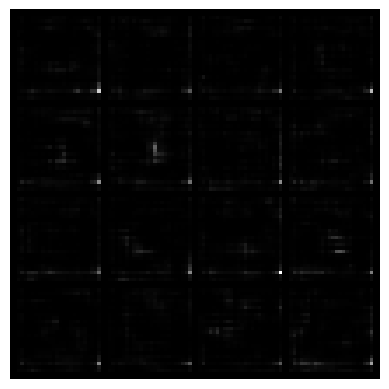

Epoch [5/20]                        Batch 337/337 Discriminator Loss: 0.6860 Generator Loss: 0.6943


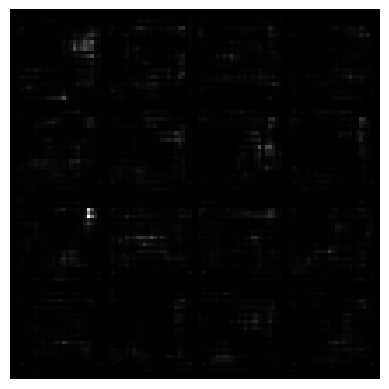

Epoch [6/20]                        Batch 337/337 Discriminator Loss: 0.6741 Generator Loss: 0.7041


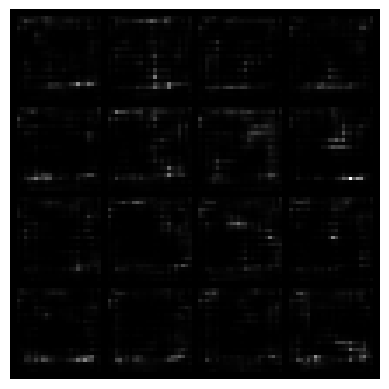

In [ ]:
for epoch in range(num_epochs):
    for i,batch in enumerate(dataloader):
        real_images=batch[0].to(device)
        valid=torch.ones(real_images.size(0),1,device=device)
        fake=torch.zeros(real_images.size(0),1,device=device)
        real_images=real_images.to(device)

        optimizer_D.zero_grad()
        z=torch.randn(real_images.size(0),latent_dim,device=device)
        fake_images=generator(z)

        real_loss=adversarial_loss(discriminator(real_images),valid)
        fake_loss=adversarial_loss(discriminator(fake_images.detach()),fake)
        d_loss=(real_loss+fake_loss)/2
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        gen_images=generator(z)
        g_loss=adversarial_loss(discriminator(gen_images),valid)
        g_loss.backward()
        optimizer_G.step()

        if (i+1)%337==0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )

    with torch.no_grad():
        z=torch.randn(16,latent_dim,device=device)
        generated=generator(z).detach().cpu()
        grid=torchvision.utils.make_grid(generated,nrow=4,normalize=True)
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.axis("off")
        plt.show()